### Lorenz System

We consider the **Lorenz system** defined by the equations

$$
\begin{aligned}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x(\rho - z) - y, \\
\dot{z} &= xy - \beta z,
\end{aligned}
$$

where $\sigma$, $\rho$, and $\beta$ are system parameters.  
The system is simulated from an off–attractor initial condition, and the resulting trajectory  

$$
U(t) = [x(t),\, y(t),\, z(t)]^\top \in \mathbb{R}^3
$$

is used as the clean reference signal.

In [1]:
# %% -----------------------------------------------
# MULTI-FIDELITY LORENZ: 10 HF AND 100 LF TRAJECTORIES
# ----------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from pysindy.feature_library import WeakPDELibrary

plt.style.use("dark_background")

rng = np.random.default_rng(12)

# Lorenz system
def lorenz(t, u, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = u
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z,
    ])


def simulate_lorenz(u0, T, dt):
    t = np.arange(0, T, dt)
    sol = solve_ivp(lorenz, (t[0], t[-1]), u0, t_eval=t, atol=1e-12, rtol=1e-12)
    return t, sol.y.T


# -----------------------------------------------------
# PARAMETERS
# -----------------------------------------------------
dt = 1e-3
T_train = 0.1
noise_hf = 0.01
noise_lf = 0.25

# HF = 10 trajectories, LF = 100 trajectories
n_hf = 10
n_lf = 100

T_test = 15.0
t_test = np.arange(0, T_test, dt)
u0_test = rng.uniform(-10, 10, size=3)
u_test = simulate_lorenz(u0_test,T_test,dt)
s = np.std(u_test[0])
print(s)

# -----------------------------------------------------
# GENERATE HF + LF DATASETS
# -----------------------------------------------------
U_hf_list = []
U_lf_list = []

for _ in range(n_hf):
    u0 = rng.uniform(-10, 10, size=3)
    t, U = simulate_lorenz(u0, T_train, dt)
    U_hf_list.append(U + noise_hf * s * rng.standard_normal(U.shape))

for _ in range(n_lf):
    u0 = rng.uniform(-10, 10, size=3)
    t, U = simulate_lorenz(u0, T_train, dt)
    U_lf_list.append(U + noise_lf * s * rng.standard_normal(U.shape))

U_mf_list = U_hf_list + U_lf_list


# -----------------------------------------------------
# BUILD WEAK LIBRARY + ENSEMBLE OPTIMIZERS
# -----------------------------------------------------
T_grid = t[:, None]

poly = ps.PolynomialLibrary(degree=2, include_bias=False)
weak_lib = WeakPDELibrary(
    function_library=poly,
    derivative_order=1,
    spatiotemporal_grid=T_grid,
    include_bias=False,
)

def make_ens():
    return ps.EnsembleOptimizer(ps.STLSQ(threshold=0.5, alpha=1e-12),n_models=20,
                                bagging=True)

opt_hf   = make_ens()
opt_lf   = make_ens()
opt_mf   = make_ens()
opt_mfw  = make_ens()

model_hf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_hf)
model_lf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_lf)
model_mf   = ps.SINDy(feature_library=weak_lib, optimizer=opt_mf)
model_mfw  = ps.SINDy(feature_library=weak_lib, optimizer=opt_mfw)

# Fit
model_hf.fit(U_hf_list, t=t)
model_lf.fit(U_lf_list, t=t)
model_mf.fit(U_mf_list, t=t)

weights = [1/noise_hf**2]*n_hf + [1/noise_lf**2]*n_lf
model_mfw.fit(U_mf_list, t=t, sample_weight=weights)

model_hf.print()
model_lf.print()
model_mf.print()
model_mfw.print()

# -----------------------------------------------------
# FORECASTING HELPERS
# -----------------------------------------------------
def build_forecast_model(coef):
    model = ps.SINDy(feature_library=poly, optimizer=ps.STLSQ(alpha=0))
    model.fit(U_hf_list[0], t=t)  # initialise shapes
    C = np.array(coef, dtype=float)
    C[~np.isfinite(C)] = 0
    C = np.clip(C, -200, 200)
    model.optimizer.coef_ = C
    return model

import tqdm
def simulate_ensemble(model_weak, u0_test, t_test):
    preds = []
    for coef in tqdm.tqdm(model_weak.optimizer.coef_list):
        try:
            m = build_forecast_model(coef)
            preds.append(m.simulate(u0_test, t_test))
        except:
            preds.append(np.nan*np.zeros((len(t_test),3)))
    P = np.array(preds)
    return np.nanmean(P, axis=0), np.nanstd(P, axis=0)






4.330127009299689


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


(x0)' = -9.894 x0 + 9.915 x1
(x1)' = 27.953 x0 + -0.969 x1 + -0.992 x0 x2
(x2)' = -2.716 x2 + 1.001 x0 x1
(x0)' = -8.704 x0 + 9.390 x1
(x1)' = 27.165 x0 + -0.868 x0 x2
(x2)' = -1.217 x0 + 1.050 x1 + -1.367 x2 + 0.898 x0 x1
(x0)' = -9.119 x0 + 9.492 x1
(x1)' = 27.262 x0 + -0.894 x0 x2
(x2)' = -0.808 x0 + 0.812 x1 + -1.397 x2 + 0.910 x0 x1
(x0)' = -9.862 x0 + 9.933 x1
(x1)' = 27.937 x0 + -0.957 x1 + -0.993 x0 x2
(x2)' = -2.684 x2 + 0.999 x0 x1


In [4]:
# -----------------------------------------------------
# FORECAST COMPARISON
# -----------------------------------------------------

T_test = 10.0
t_test = np.arange(0, T_test, dt)
u0_test = rng.uniform(-10, 10, size=3)
u0_test[2]+=30

# True trajectory
_, U_true = simulate_lorenz(u0_test, T_test, dt)

# Ensemble predictions
# U_hf_mean,  U_hf_std  = simulate_ensemble(model_hf,  u0_test, t_test)
# U_lf_mean,  U_lf_std  = simulate_ensemble(model_lf,  u0_test, t_test)
U_mf_mean,  U_mf_std  = simulate_ensemble(model_mf,  u0_test, t_test)
U_wmf_mean, U_wmf_std = simulate_ensemble(model_mfw, u0_test, t_test)


100%|██████████| 20/20 [01:30<00:00,  4.52s/it]


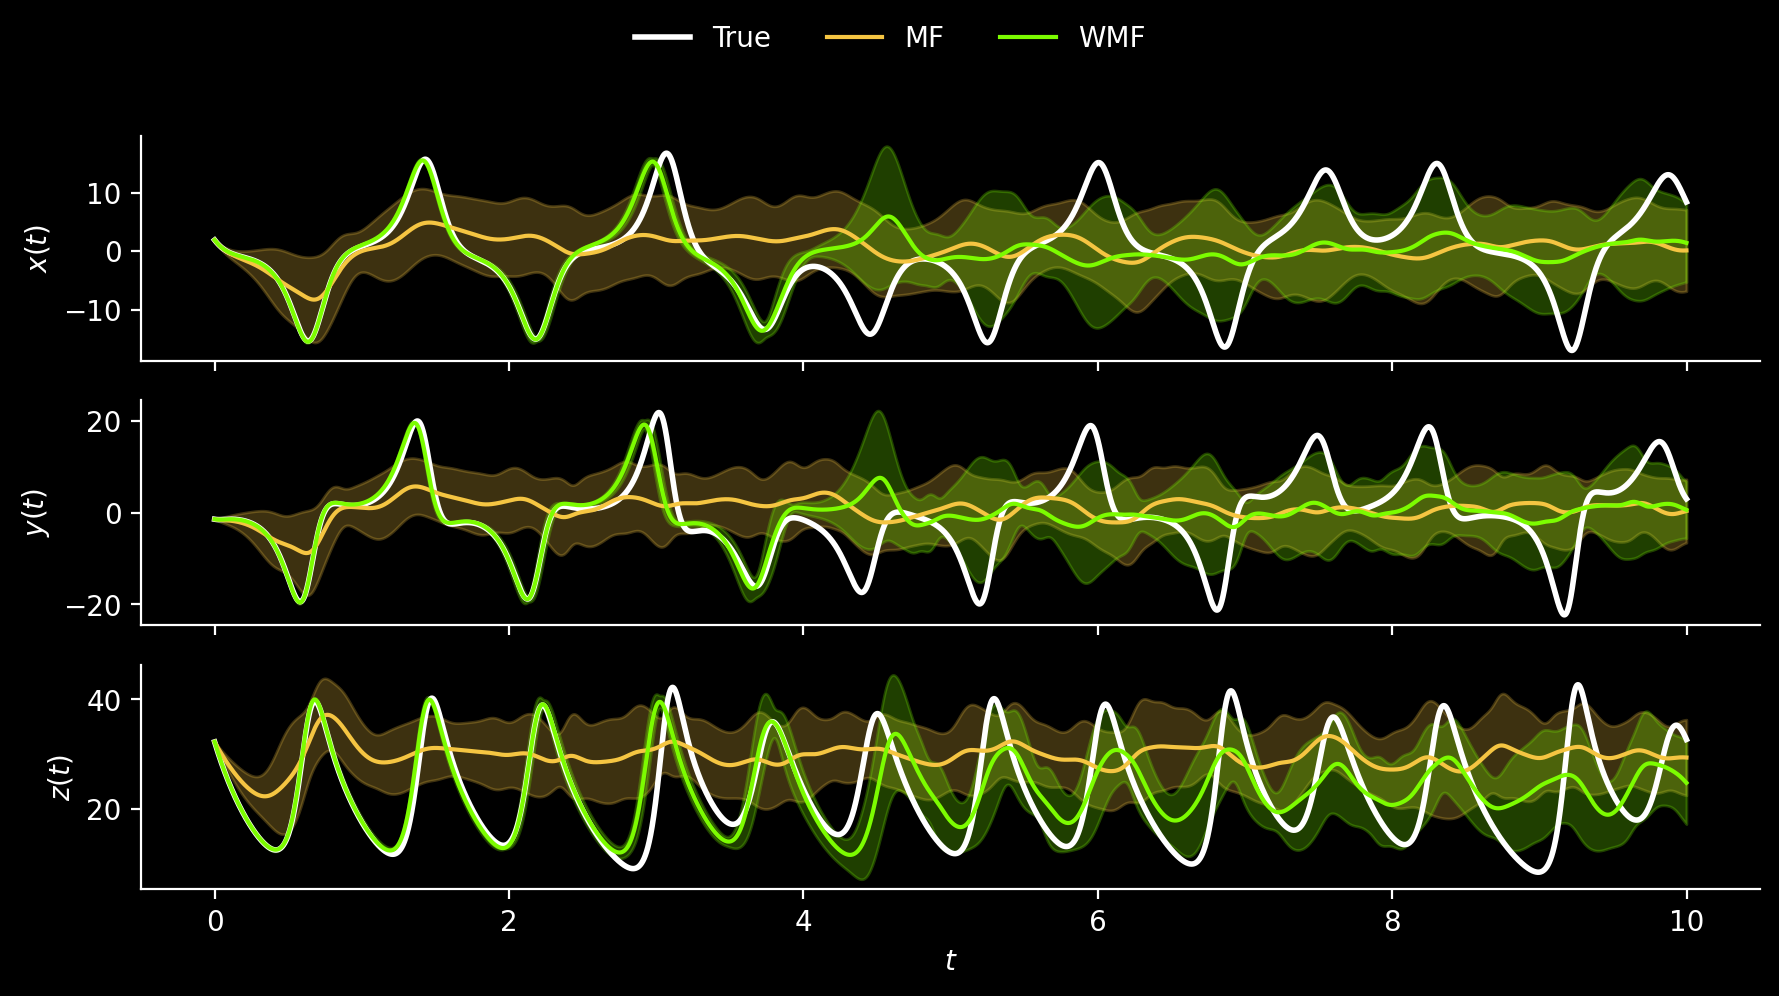

In [5]:

# -----------------------------------------------------
# PLOT (dark background, uncertainty)
# -----------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True, dpi=200)

coords = [r"$x(t)$", r"$y(t)$", r"$z(t)$"]
col_true = "white"
col_hf   = "#4296f5"
col_lf   = "#f56942"
col_mf   = "#f5c542"
col_mfw  = "#7CFC00"

for i, ax in enumerate(axes):
    # true
    ax.plot(t_test, U_true[:, i], color=col_true, lw=2.0, label="True" if i == 0 else None)
    
    # ax.fill_between(t_test, U_lf_mean[:,i]-U_lf_std[:,i],
    #                           U_lf_mean[:,i]+U_lf_std[:,i],
    #                 color=col_mf, alpha=0.25)
    # ax.plot(t_test, U_lf_mean[:,i], color=col_lf, lw=1.5, label="LF" if i==0 else None)
    
    ax.fill_between(t_test, U_mf_mean[:,i]-U_mf_std[:,i],
                              U_mf_mean[:,i]+U_mf_std[:,i],
                    color=col_mf, alpha=0.25)
    ax.plot(t_test, U_mf_mean[:,i], color=col_mf, lw=1.5, label="MF" if i==0 else None)

    # WMF
    ax.fill_between(t_test, U_wmf_mean[:,i]-U_wmf_std[:,i],
                              U_wmf_mean[:,i]+U_wmf_std[:,i],
                    color=col_mfw, alpha=0.25)
    ax.plot(t_test, U_wmf_mean[:,i], color=col_mfw, lw=1.5, label="WMF" if i==0 else None)
    
    # ax.fill_between(t_test, U_hf_mean[:,i]-U_hf_std[:,i],
    #                           U_hf_mean[:,i]+U_hf_std[:,i],
    #                 color=col_hf, alpha=0.25)
    # ax.plot(t_test, U_hf_mean[:,i], color=col_hf, lw=1.5, label="HF" if i==0 else None)

    ax.set_ylabel(coords[i])
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel(r"$t$")
fig.legend(loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()
